In [11]:
import numpy as np

In [12]:
def b(sigma,alpha,x):
    return sigma*(1+alpha*np.tanh(x))

def UGrad(x1,x2):
    return np.array([x1*(x1**2-1),x2*(x2**2-1)])

In [13]:
N = 10**2
dt = 10**(-2)
T = 10
M = int(T/dt)
W = np.zeros(shape=(M+1,N))
alphav = [0,0.1,0.3,0.5]
sigmav = [0.1,0.3,0.5,2]
X = np.zeros(shape=(M+1,N,len(alphav),len(sigmav),2))


In [14]:
X.shape

(1001, 100, 4, 4, 2)

In [15]:
for i in range(N):
    for t in range(1,M+1):
        W[t,i] = W[t-1,i]+np.sqrt(dt)*np.random.normal(0,1,1)

C:\Users\trist\AppData\Local\Temp\ipykernel_25776\340492558.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  W[t,i] = W[t-1,i]+np.sqrt(dt)*np.random.normal(0,1,1)


In [16]:
for k in range(len(sigmav)):
    for j in range(len(alphav)):
        for i in range(N):
            X[0,i,j,k,:] = np.random.normal(0,1,2)
            for t in range(1,M+1):
                X[t,i,j,k,:] = X[t-1,i,j,k,:]-dt*UGrad(X[t-1,i,j,k,0],X[t-1,i,j,k,1])+(W[t,i]-W[t-1,i])*b(sigmav[k],alphav[j],X[t-1,i,j,k,:])

In [17]:
import matplotlib.pyplot as plt

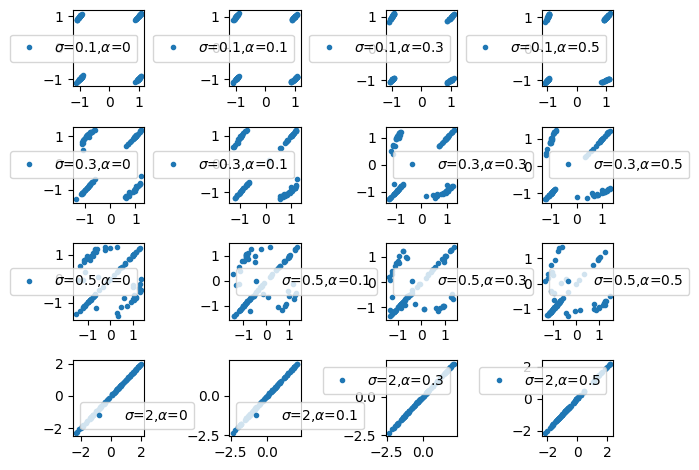

In [18]:
i = 1
for k in range(len(sigmav)):
    for j in range(len(alphav)):
        plt.subplot(4,4,i)
        plt.plot(X[-1,:,j,k,0],X[-1,:,j,k,1],'.',
                 label=fr"$\sigma$={sigmav[k]},$\alpha$={alphav[j]}")
        i += 1
        plt.legend()

plt.tight_layout()
plt.show()